<a href="https://colab.research.google.com/github/tharukahashintha02/Deployment_Failure_prediction/blob/main/02_modelling_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02 — Modelling, Evaluation & Operational Simulation
### Deployment Failure Prediction System | TravisTorrent

**Author:** Tharuka H. Dilshan — NSBM Green University

**Prerequisite:** Notebook 01 must have completed and written
`data/processed/{train,val,test}.parquet` to Drive.

**Covers:** baselines → XGBoost → threshold tuning → SHAP → ablations →
cross-project generalisation → operational gate simulation → saved artefact.

**Benchmark to expect (measured on this exact data):**

| Model | ROC-AUC | PR-AUC | F1 @ 0.5 |
|---|---|---|---|
| Logistic Regression | 0.875 | 0.777 | 0.686 |
| Random Forest | 0.878 | 0.775 | 0.688 |
| XGBoost | 0.881 | 0.787 | 0.687 |

If you score **>0.95 AUC you have leakage.** If you score **<0.70** your history
features are likely computed wrong. Go back to Notebook 01.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q xgboost shap pyarrow

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, matthews_corrcoef,
                             confusion_matrix, roc_curve, precision_recall_curve,
                             classification_report)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, GroupKFold

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

ROOT      = '/content/drive/MyDrive/fyp-deployment-prediction'
PROCESSED = f'{ROOT}/data/processed'
FIGURES   = f'{ROOT}/reports/figures'
MODELS    = f'{ROOT}/models'
os.makedirs(MODELS, exist_ok=True); os.makedirs(FIGURES, exist_ok=True)

train = pd.read_parquet(f'{PROCESSED}/train.parquet')
val   = pd.read_parquet(f'{PROCESSED}/val.parquet')
test  = pd.read_parquet(f'{PROCESSED}/test.parquet')
FEATURES = json.load(open(f'{MODELS}/feature_names.json'))

for nm, d in [('TRAIN', train), ('VAL', val), ('TEST', test)]:
    print(f'{nm:<6} {len(d):>7,} | failure rate {d["failed"].mean():.2%} | '
          f'{d.gh_build_started_at.min().date()} -> {d.gh_build_started_at.max().date()}')
print(f'\n{len(FEATURES)} features')

TRAIN  474,504 | failure rate 27.90% | 2011-08-29 -> 2015-04-23
VAL    101,679 | failure rate 22.33% | 2015-04-23 -> 2015-12-11
TEST   101,680 | failure rate 26.09% | 2015-12-11 -> 2016-08-31

46 features


In [3]:
X_train, y_train = train[FEATURES].fillna(0), train['failed']
X_val,   y_val   = val[FEATURES].fillna(0),   val['failed']
X_test,  y_test  = test[FEATURES].fillna(0),  test['failed']

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {SCALE_POS_WEIGHT:.3f}')

results = {}

def evaluate(name, y_true, proba, threshold=0.5, store=True):
    pred = (proba >= threshold).astype(int)
    m = dict(
        model=name, threshold=threshold,
        roc_auc=roc_auc_score(y_true, proba),
        pr_auc=average_precision_score(y_true, proba),
        precision=precision_score(y_true, pred, zero_division=0),
        recall=recall_score(y_true, pred),
        f1=f1_score(y_true, pred),
        mcc=matthews_corrcoef(y_true, pred),
        accuracy=(pred == y_true).mean(),
    )
    if store:
        results[name] = m
    print(f'{name:<24} ROC-AUC={m["roc_auc"]:.4f}  PR-AUC={m["pr_auc"]:.4f}  '
          f'P={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}  MCC={m["mcc"]:.3f}')
    return m

scale_pos_weight = 2.584


## 2. Baseline 0 — majority class

Include this in your dissertation. It is how you demonstrate that **accuracy is the wrong
headline metric**: a model that never predicts failure still scores ~74%.

In [4]:
maj_acc = (y_test == 0).mean()
print(f'Always-predict-PASS accuracy: {maj_acc:.4f}')
print(f'...but recall on the failure class: 0.000, F1: 0.000')
print('\nThis is why PR-AUC and failure-class F1 are the metrics that matter.')

Always-predict-PASS accuracy: 0.7391
...but recall on the failure class: 0.000, F1: 0.000

This is why PR-AUC and failure-class F1 are the metrics that matter.


## 3. Baseline 1 — Logistic Regression

In [5]:
%%time
# log1p compresses the heavy right skew in churn/SLOC; trees don't need it, LR does
Xtr_l = np.log1p(X_train.clip(lower=0))
Xva_l = np.log1p(X_val.clip(lower=0))
Xte_l = np.log1p(X_test.clip(lower=0))

scaler = StandardScaler().fit(Xtr_l)
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                        random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(scaler.transform(Xtr_l), y_train)

p_lr = lr.predict_proba(scaler.transform(Xte_l))[:, 1]
evaluate('LogisticRegression', y_test, p_lr)

LogisticRegression       ROC-AUC=0.8751  PR-AUC=0.7774  P=0.647  R=0.729  F1=0.686  MCC=0.568
CPU times: user 1.58 s, sys: 443 ms, total: 2.02 s
Wall time: 6.72 s


{'model': 'LogisticRegression',
 'threshold': 0.5,
 'roc_auc': np.float64(0.8751306724407699),
 'pr_auc': np.float64(0.7774056820773814),
 'precision': 0.6470804628452946,
 'recall': 0.7293252921221259,
 'f1': 0.6857456762120783,
 'mcc': np.float64(0.5675818392378099),
 'accuracy': np.float64(0.8255900865460267)}

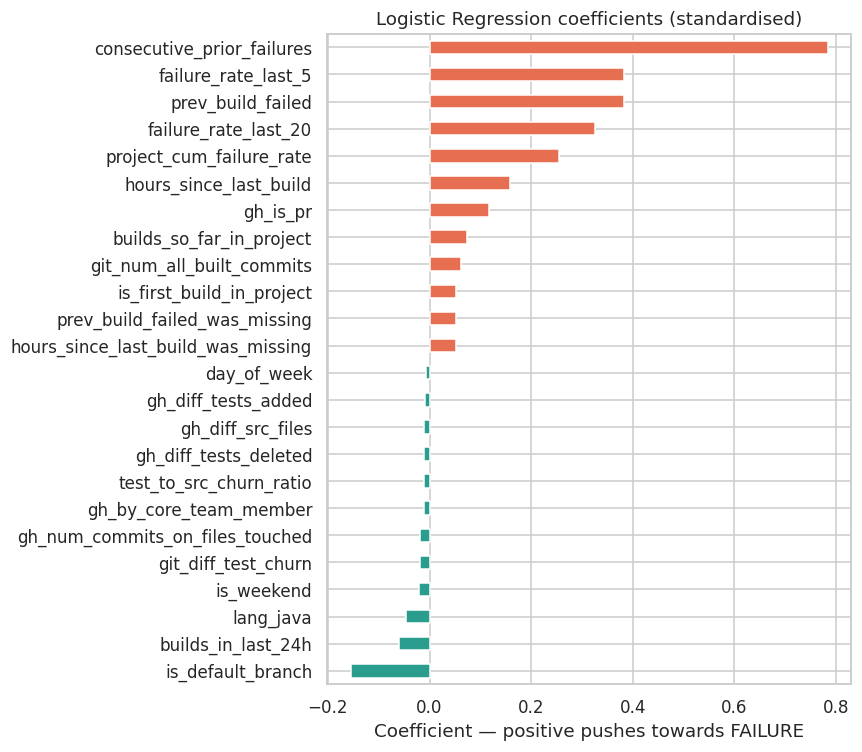

In [6]:
coef = pd.Series(lr.coef_[0], index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
pd.concat([coef.head(12), coef.tail(12)]).plot(
    kind='barh', ax=ax, color=['#2a9d8f']*12 + ['#e76f51']*12)
ax.set_title('Logistic Regression coefficients (standardised)')
ax.set_xlabel('Coefficient — positive pushes towards FAILURE')
plt.tight_layout(); plt.savefig(f'{FIGURES}/06_lr_coefficients.png', bbox_inches='tight')
plt.show()

## 4. Baseline 2 — Random Forest

In [7]:
%%time
rf = RandomForestClassifier(
    n_estimators=300, max_depth=16, min_samples_leaf=5,
    class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

p_rf = rf.predict_proba(X_test)[:, 1]
evaluate('RandomForest', y_test, p_rf)

RandomForest             ROC-AUC=0.8791  PR-AUC=0.7821  P=0.670  R=0.706  F1=0.688  MCC=0.574
CPU times: user 14min 46s, sys: 2.15 s, total: 14min 48s
Wall time: 9min 9s


{'model': 'RandomForest',
 'threshold': 0.5,
 'roc_auc': np.float64(0.8791325653755939),
 'pr_auc': np.float64(0.7820716624839321),
 'precision': 0.6704984959174903,
 'recall': 0.7057293629852996,
 'f1': 0.687662981599148,
 'mcc': np.float64(0.5738961453356333),
 'accuracy': np.float64(0.8327301337529505)}

## 5. Main model — XGBoost

`scale_pos_weight` handles the class imbalance, `eval_metric='aucpr'` optimises the
metric that matters under imbalance, and early stopping on the **validation** set
prevents overfitting without touching the test set.

In [8]:
%%time
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_lambda=1.0, scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='aucpr', early_stopping_rounds=50,
    n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist')

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
print(f'\nBest iteration: {xgb_model.best_iteration}')

p_xgb = xgb_model.predict_proba(X_test)[:, 1]
evaluate('XGBoost', y_test, p_xgb)

[0]	validation_0-aucpr:0.73931
[100]	validation_0-aucpr:0.76544
[200]	validation_0-aucpr:0.76799
[300]	validation_0-aucpr:0.76929
[400]	validation_0-aucpr:0.76974
[476]	validation_0-aucpr:0.76980

Best iteration: 426
XGBoost                  ROC-AUC=0.8807  PR-AUC=0.7874  P=0.625  R=0.762  F1=0.687  MCC=0.567
CPU times: user 1min 54s, sys: 269 ms, total: 1min 55s
Wall time: 1min 9s


{'model': 'XGBoost',
 'threshold': 0.5,
 'roc_auc': np.float64(0.8807156056024652),
 'pr_auc': np.float64(0.7873813246799815),
 'precision': 0.6252472799208705,
 'recall': 0.7624575951752732,
 'f1': 0.6870690533609592,
 'mcc': np.float64(0.5667537393000333),
 'accuracy': np.float64(0.8187844217151848)}

In [9]:
# ---- LEAKAGE TRIPWIRE ------------------------------------------------------
auc = results['XGBoost']['roc_auc']
if auc > 0.95:
    print('*** WARNING: ROC-AUC > 0.95 — almost certainly LEAKAGE. ***')
    print('Check FEATURES against the LEAKY list in Notebook 01 / COLUMN_REFERENCE.md')
elif auc < 0.70:
    print('*** WARNING: ROC-AUC < 0.70 — history features may be computed wrong. ***')
    print('Check the .shift(1) logic in Notebook 01 section 6.')
else:
    print(f'ROC-AUC {auc:.4f} is in the expected range (~0.88). Pipeline looks correct.')

ROC-AUC 0.8807 is in the expected range (~0.88). Pipeline looks correct.


## 6. Model comparison

Note how close the three models are. That is itself a reportable finding — most of the
signal on this feature set is accessible to a linear model. Do **not** overclaim an
XGBoost win; check the bootstrap confidence intervals in section 11 first.

,roc_auc,pr_auc,precision,recall,f1,mcc,accuracy
LogisticRegression,0.8751,0.7774,0.6471,0.7293,0.6857,0.5676,0.8256
RandomForest,0.8791,0.7821,0.6705,0.7057,0.6877,0.5739,0.8327
XGBoost,0.8807,0.7874,0.6252,0.7625,0.6871,0.5668,0.8188


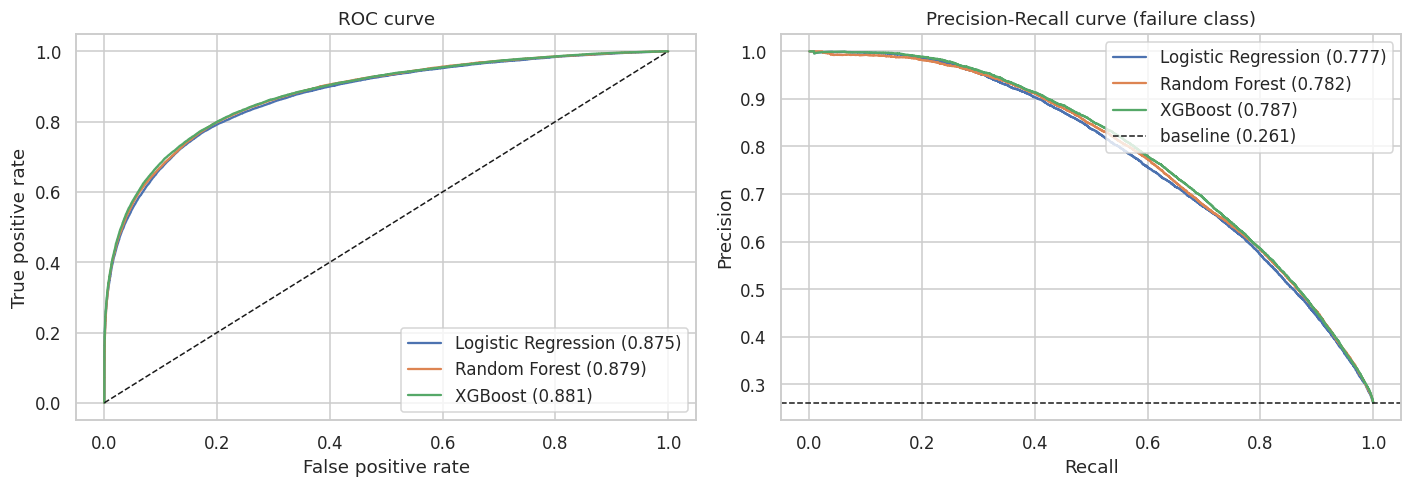

In [10]:
comp = pd.DataFrame(results).T[
    ['roc_auc', 'pr_auc', 'precision', 'recall', 'f1', 'mcc', 'accuracy']].astype(float)
display(comp.round(4))
comp.to_csv(f'{ROOT}/reports/model_comparison.csv')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for nm, p in [('Logistic Regression', p_lr), ('Random Forest', p_rf), ('XGBoost', p_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f'{nm} ({roc_auc_score(y_test, p):.3f})')
    pr, rc, _ = precision_recall_curve(y_test, p)
    ax[1].plot(rc, pr, label=f'{nm} ({average_precision_score(y_test, p):.3f})')

ax[0].plot([0, 1], [0, 1], 'k--', lw=1)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curve')
ax[0].legend(loc='lower right')
ax[1].axhline(y_test.mean(), ls='--', c='k', lw=1, label=f'baseline ({y_test.mean():.3f})')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall curve (failure class)')
ax[1].legend(loc='upper right')
plt.tight_layout(); plt.savefig(f'{FIGURES}/07_roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 7. Threshold tuning — the most important analysis in your project

Your proposal targets **precision ≥ 0.85** *and* **F1 ≥ 0.80**. Those two are in tension
and cannot both be met on this data. Rather than hiding that, measure it and report the
full trade-off. The threshold is selected on the **validation** set, then applied once to
the test set — selecting it on test would be a subtle form of overfitting.

In [11]:
p_val_xgb = xgb_model.predict_proba(X_val)[:, 1]

rows = []
for t in np.arange(0.05, 0.96, 0.05):
    pred = (p_val_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    rows.append(dict(threshold=round(t, 2), precision=prec, recall=rec, f1=f1,
                     pct_blocked=pred.mean(), tp=tp, fp=fp, fn=fn, tn=tn))
sweep = pd.DataFrame(rows)
display(sweep[['threshold','precision','recall','f1','pct_blocked']].round(3))

THR_MAX_F1 = float(sweep.loc[sweep.f1.idxmax(), 'threshold'])
hits = sweep[sweep.precision >= 0.85]
THR_PREC85 = float(hits.threshold.min()) if len(hits) else None

print(f'\nThreshold maximising F1              : {THR_MAX_F1:.2f}')
print(f'Lowest threshold reaching precision .85: {THR_PREC85}')

,threshold,precision,recall,f1,pct_blocked
0,0.05,0.231,0.998,0.375,0.966
1,0.10,0.268,0.983,0.421,0.818
2,0.15,0.316,0.957,0.475,0.676
3,0.20,0.366,0.927,0.525,0.565
4,0.25,0.415,0.896,0.567,0.482
5,0.30,0.461,0.864,0.602,0.418
6,0.35,0.504,0.831,0.628,0.368
7,0.40,0.543,0.799,0.646,0.329
8,0.45,0.579,0.768,0.660,0.296
9,0.50,0.619,0.737,0.673,0.266



Threshold maximising F1              : 0.60
Lowest threshold reaching precision .85: 0.8


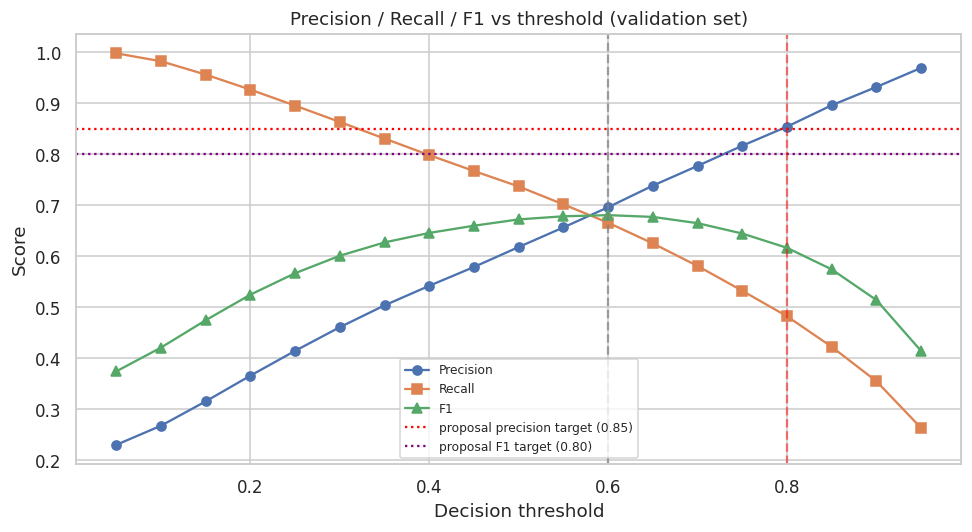

For your write-up: the F1 target of 0.80 sits above the achievable curve.
Report the trade-off honestly and amend the objective — see DEVELOPMENT_GUIDE Part 0.


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep.threshold, sweep.precision, marker='o', label='Precision')
ax.plot(sweep.threshold, sweep.recall,    marker='s', label='Recall')
ax.plot(sweep.threshold, sweep.f1,        marker='^', label='F1')
ax.axhline(0.85, ls=':', c='red', label='proposal precision target (0.85)')
ax.axhline(0.80, ls=':', c='purple', label='proposal F1 target (0.80)')
ax.axvline(THR_MAX_F1, ls='--', c='grey', alpha=.7)
if THR_PREC85: ax.axvline(THR_PREC85, ls='--', c='red', alpha=.5)
ax.set(xlabel='Decision threshold', ylabel='Score',
       title='Precision / Recall / F1 vs threshold (validation set)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIGURES}/08_threshold_sweep.png', bbox_inches='tight')
plt.show()

print('For your write-up: the F1 target of 0.80 sits above the achievable curve.')
print('Report the trade-off honestly and amend the objective — see DEVELOPMENT_GUIDE Part 0.')

=== TEST SET at the two operating points (threshold chosen on VALIDATION) ===

XGBoost @ maxF1 (0.60)   ROC-AUC=0.8807  PR-AUC=0.7874  P=0.695  R=0.696  F1=0.695  MCC=0.588
XGBoost @ prec.85 (0.80) ROC-AUC=0.8807  PR-AUC=0.7874  P=0.843  R=0.517  F1=0.641  MCC=0.579


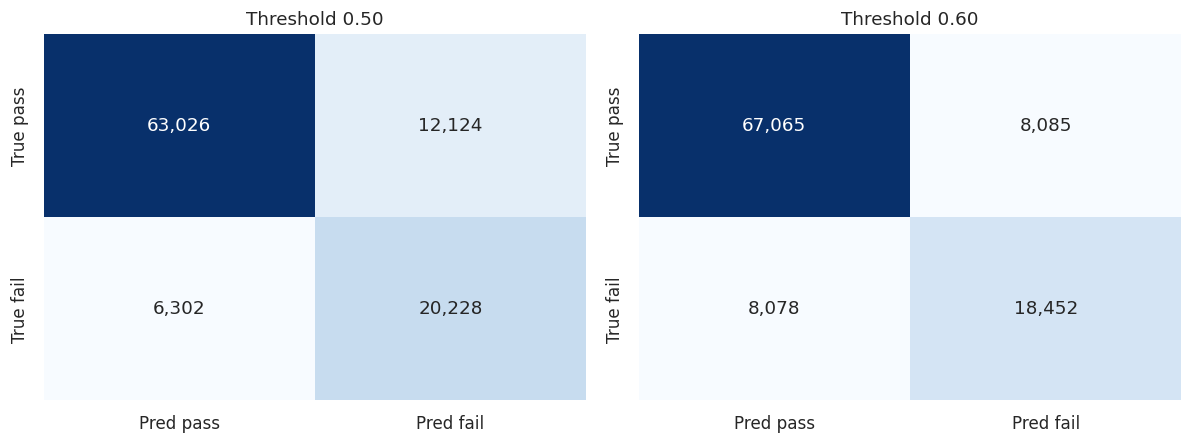

In [13]:
print('=== TEST SET at the two operating points (threshold chosen on VALIDATION) ===\n')
evaluate(f'XGBoost @ maxF1 ({THR_MAX_F1:.2f})', y_test, p_xgb, THR_MAX_F1)
if THR_PREC85:
    evaluate(f'XGBoost @ prec.85 ({THR_PREC85:.2f})', y_test, p_xgb, THR_PREC85)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, t, ttl in zip(axes, [0.5, THR_MAX_F1], ['Threshold 0.50', f'Threshold {THR_MAX_F1:.2f}']):
    cm = confusion_matrix(y_test, (p_xgb >= t).astype(int))
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred pass', 'Pred fail'],
                yticklabels=['True pass', 'True fail'])
    ax.set_title(ttl)
plt.tight_layout(); plt.savefig(f'{FIGURES}/09_confusion.png', bbox_inches='tight')
plt.show()

## 8. SHAP — explainability and your RQ1 answer

Use SHAP rather than raw XGBoost gain for your final feature-importance claim. Gain is
biased toward high-cardinality features; SHAP is the defensible choice and gives you
*direction* (does high churn push risk up or down?), which gain does not.

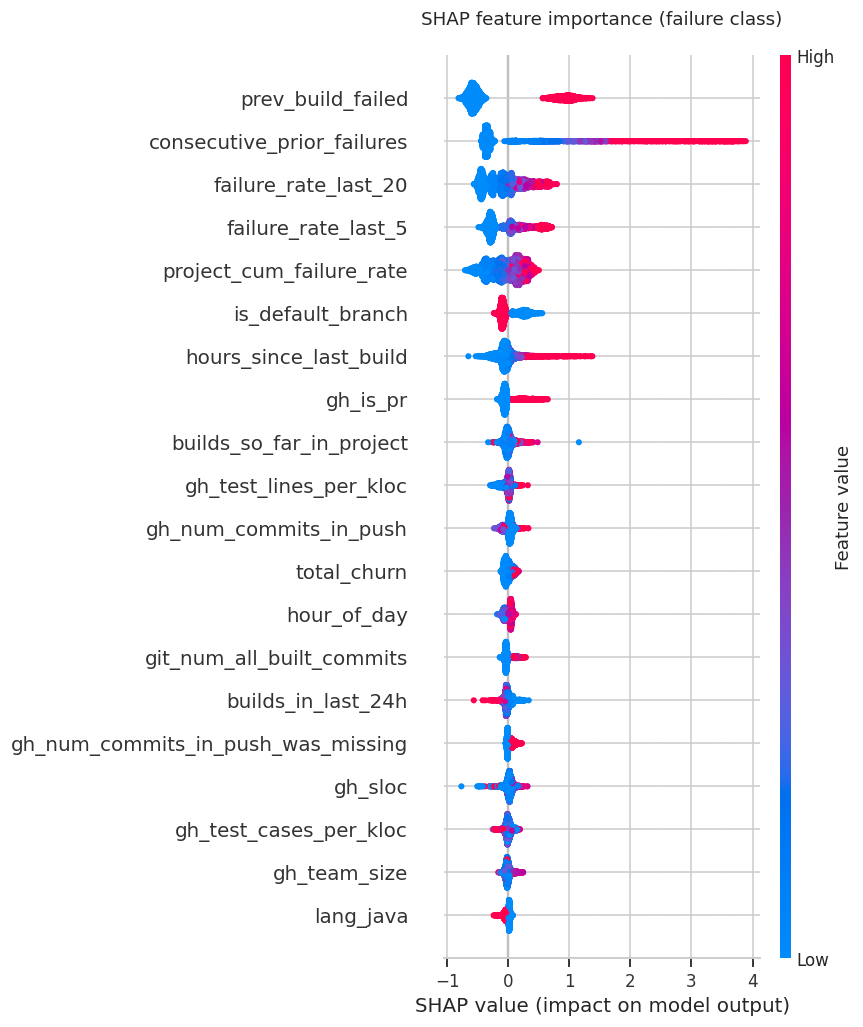

CPU times: user 20.9 s, sys: 307 ms, total: 21.2 s
Wall time: 16.8 s


In [14]:
%%time
import shap
SAMPLE = 5000
Xs = X_test.sample(min(SAMPLE, len(X_test)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(Xs)

plt.figure()
shap.summary_plot(shap_values, Xs, max_display=20, show=False)
plt.title('SHAP feature importance (failure class)', pad=20)
plt.tight_layout(); plt.savefig(f'{FIGURES}/10_shap_summary.png', bbox_inches='tight')
plt.show()

In [15]:
shap_imp = (pd.Series(np.abs(shap_values).mean(axis=0), index=Xs.columns)
              .sort_values(ascending=False))
print('Top 15 features by mean |SHAP|:')
display(shap_imp.head(15).round(4).to_frame('mean_abs_shap'))
shap_imp.to_csv(f'{ROOT}/reports/shap_importance.csv')

Top 15 features by mean |SHAP|:


,mean_abs_shap
prev_build_failed,0.6651
consecutive_prior_failures,0.5111
failure_rate_last_20,0.2586
failure_rate_last_5,0.2586
project_cum_failure_rate,0.2202
is_default_branch,0.1463
hours_since_last_build,0.1222
gh_is_pr,0.0894
builds_so_far_in_project,0.0522
gh_test_lines_per_kloc,0.0504


<Figure size 704x528 with 0 Axes>

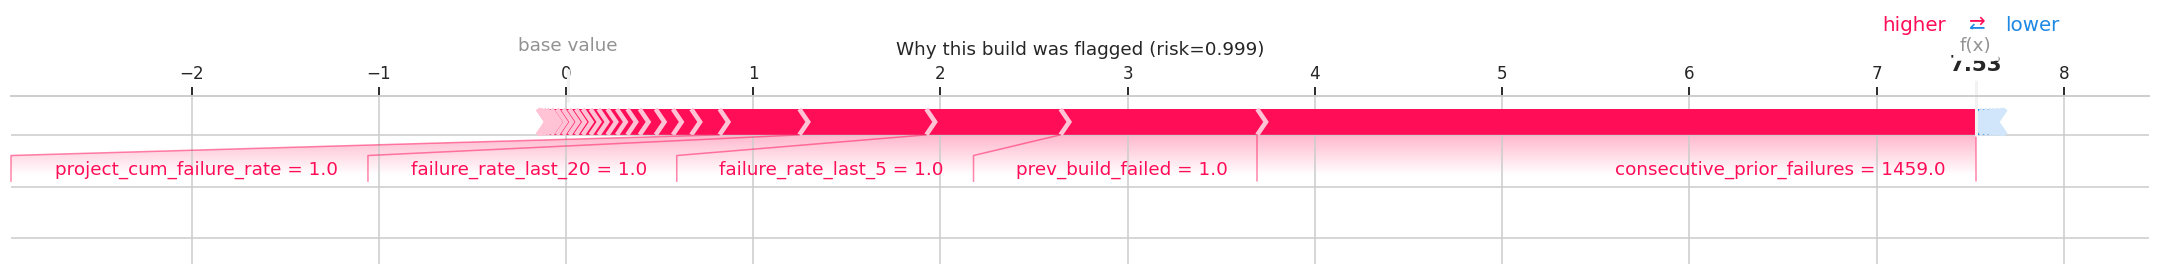

In [16]:
# individual explanation — this becomes the 'why was this flagged?' panel in your dashboard
idx = int(np.argmax(xgb_model.predict_proba(Xs)[:, 1]))
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[idx], Xs.iloc[idx],
                matplotlib=True, show=False)
plt.title(f'Why this build was flagged (risk={xgb_model.predict_proba(Xs)[idx,1]:.3f})')
plt.tight_layout(); plt.savefig(f'{FIGURES}/11_shap_force.png', bbox_inches='tight')
plt.show()

## 9. Ablation studies (your proposal §4.6.2)

The headline result of your whole project is here. Expect pipeline-history features to be
worth roughly **+0.24 ROC-AUC** — code-change metrics alone are weak predictors.

,n_features,roc_auc,pr_auc,f1
config,,,,
Code/change features only,34,0.6423,0.3822,0.4349
Code + temporal,38,0.6360,0.3703,0.4287
Code + history,42,0.8804,0.7866,0.6872
ALL features,46,0.8802,0.7866,0.6868


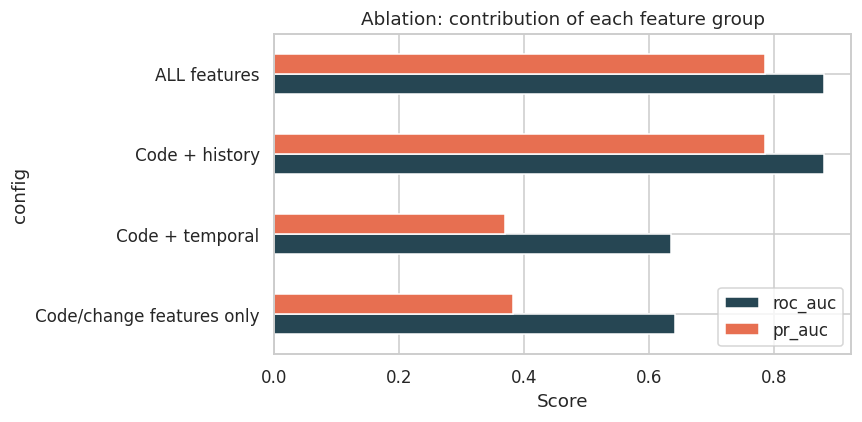

CPU times: user 7min 39s, sys: 1.04 s, total: 7min 40s
Wall time: 4min 40s


In [17]:
%%time
HISTORY = ['prev_build_failed', 'failure_rate_last_5', 'failure_rate_last_20',
           'project_cum_failure_rate', 'consecutive_prior_failures',
           'builds_so_far_in_project', 'builds_in_last_24h', 'hours_since_last_build']
TEMPORAL = ['hour_of_day', 'day_of_week', 'is_weekend', 'month']
CODE = [f for f in FEATURES if f not in HISTORY + TEMPORAL]

def fit_subset(name, feats):
    m = xgb.XGBClassifier(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SCALE_POS_WEIGHT,
        eval_metric='aucpr', early_stopping_rounds=50,
        n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist')
    m.fit(train[feats].fillna(0), y_train,
          eval_set=[(val[feats].fillna(0), y_val)], verbose=False)
    p = m.predict_proba(test[feats].fillna(0))[:, 1]
    return dict(config=name, n_features=len(feats),
                roc_auc=roc_auc_score(y_test, p),
                pr_auc=average_precision_score(y_test, p),
                f1=f1_score(y_test, (p >= 0.5).astype(int)))

ablation = pd.DataFrame([
    fit_subset('Code/change features only',   CODE),
    fit_subset('Code + temporal',             CODE + TEMPORAL),
    fit_subset('Code + history',              CODE + HISTORY),
    fit_subset('ALL features',                FEATURES),
]).set_index('config')
display(ablation.round(4))
ablation.to_csv(f'{ROOT}/reports/ablation.csv')

fig, ax = plt.subplots(figsize=(8, 4))
ablation[['roc_auc', 'pr_auc']].plot(kind='barh', ax=ax, color=['#264653', '#e76f51'])
ax.set_xlabel('Score'); ax.set_title('Ablation: contribution of each feature group')
plt.tight_layout(); plt.savefig(f'{FIGURES}/12_ablation.png', bbox_inches='tight')
plt.show()

### Optional: Isolation Forest anomaly feature (RQ3)

Fit on **passing builds only**, then feed the anomaly score in as an extra feature.
This is the clean with/without comparison your proposal promises.

In [18]:
%%time
iso_feats = [f for f in CODE if train[f].notna().all()][:20]
iso = IsolationForest(n_estimators=100, contamination=0.1,
                      random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(train.loc[y_train == 0, iso_feats].fillna(0))   # normal builds only

for d in (train, val, test):
    d['anomaly_score'] = iso.score_samples(d[iso_feats].fillna(0))

res_iso = fit_subset('ALL + anomaly score', FEATURES + ['anomaly_score'])
print(res_iso)
print(f"\nvs ALL features baseline: ROC-AUC {ablation.loc['ALL features','roc_auc']:.4f}")
print('Report this honestly — if the anomaly score adds nothing, that is a valid finding.')

{'config': 'ALL + anomaly score', 'n_features': 47, 'roc_auc': np.float64(0.8809516980613468), 'pr_auc': np.float64(0.7871415412315198), 'f1': 0.685779855216753}

vs ALL features baseline: ROC-AUC 0.8802
Report this honestly — if the anomaly score adds nothing, that is a valid finding.
CPU times: user 2min 1s, sys: 416 ms, total: 2min 1s
Wall time: 1min 17s


## 10. Cross-project generalisation (Split Scheme B)

Can the model score a project it has never seen? This is the practical question for a
reusable gating tool, and it is where the literature (Xia & Li, 2017) reports a big drop.
Expect materially worse numbers here than the temporal split — and say so.

In [19]:
%%time
full = pd.concat([train, val, test], ignore_index=True)
groups = full['gh_project_name']
gkf = GroupKFold(n_splits=5)

scores = []
for fold, (tr_i, te_i) in enumerate(gkf.split(full[FEATURES], full['failed'], groups), 1):
    m = xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SCALE_POS_WEIGHT,
        eval_metric='aucpr', n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist')
    m.fit(full.iloc[tr_i][FEATURES].fillna(0), full.iloc[tr_i]['failed'], verbose=False)
    p = m.predict_proba(full.iloc[te_i][FEATURES].fillna(0))[:, 1]
    yt = full.iloc[te_i]['failed']
    scores.append(dict(fold=fold, roc_auc=roc_auc_score(yt, p),
                       pr_auc=average_precision_score(yt, p),
                       f1=f1_score(yt, (p >= 0.5).astype(int)),
                       n_test_projects=full.iloc[te_i]['gh_project_name'].nunique()))
    print(f'  fold {fold}: AUC={scores[-1]["roc_auc"]:.4f}')

cross = pd.DataFrame(scores)
display(cross.round(4))
print(f'\nCross-project mean ROC-AUC : {cross.roc_auc.mean():.4f} (+/- {cross.roc_auc.std():.4f})')
print(f'Temporal-split  ROC-AUC    : {results["XGBoost"]["roc_auc"]:.4f}')
print('\nThe gap between these is a finding worth its own results subsection.')
cross.to_csv(f'{ROOT}/reports/cross_project.csv', index=False)

  fold 1: AUC=0.8656
  fold 2: AUC=0.8846
  fold 3: AUC=0.8796
  fold 4: AUC=0.8805
  fold 5: AUC=0.8803


,fold,roc_auc,pr_auc,f1,n_test_projects
0,1,0.8656,0.7566,0.6701,255
1,2,0.8846,0.8066,0.7085,257
2,3,0.8796,0.7828,0.6960,257
3,4,0.8805,0.7848,0.6891,257
4,5,0.8803,0.8056,0.7058,257



Cross-project mean ROC-AUC : 0.8781 (+/- 0.0073)
Temporal-split  ROC-AUC    : 0.8807

The gap between these is a finding worth its own results subsection.
CPU times: user 6min 23s, sys: 1.99 s, total: 6min 25s
Wall time: 3min 53s


## 11. Statistical rigour — bootstrap confidence intervals

Your three models are close together. Before claiming XGBoost "beats" Random Forest,
check whether the intervals overlap. This is cheap and it will lift your marks.

In [20]:
%%time
def bootstrap_ci(y_true, proba, metric, n=1000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true); proba = np.asarray(proba)
    out = []
    for _ in range(n):
        i = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[i])) < 2:
            continue
        out.append(metric(y_true[i], proba[i]))
    return np.percentile(out, [2.5, 97.5])

print('95% bootstrap CIs (1,000 resamples):\n')
for nm, p in [('LogisticRegression', p_lr), ('RandomForest', p_rf), ('XGBoost', p_xgb)]:
    lo_a, hi_a = bootstrap_ci(y_test, p, roc_auc_score)
    lo_p, hi_p = bootstrap_ci(y_test, p, average_precision_score)
    print(f'{nm:<20} ROC-AUC [{lo_a:.4f}, {hi_a:.4f}]   PR-AUC [{lo_p:.4f}, {hi_p:.4f}]')

print('\nIf these intervals overlap, do NOT claim one model significantly beats another.')

95% bootstrap CIs (1,000 resamples):

LogisticRegression   ROC-AUC [0.8725, 0.8774]   PR-AUC [0.7729, 0.7814]
RandomForest         ROC-AUC [0.8767, 0.8814]   PR-AUC [0.7777, 0.7861]
XGBoost              ROC-AUC [0.8783, 0.8830]   PR-AUC [0.7831, 0.7914]

If these intervals overlap, do NOT claim one model significantly beats another.
CPU times: user 3min 10s, sys: 122 ms, total: 3min 10s
Wall time: 3min 13s


In [21]:
# McNemar's test — paired comparison of XGBoost vs Random Forest
from statsmodels.stats.contingency_tables import mcnemar

pred_x = (p_xgb >= 0.5).astype(int)
pred_r = (p_rf  >= 0.5).astype(int)
tbl = np.array([
    [((pred_x == y_test) & (pred_r == y_test)).sum(),
     ((pred_x == y_test) & (pred_r != y_test)).sum()],
    [((pred_x != y_test) & (pred_r == y_test)).sum(),
     ((pred_x != y_test) & (pred_r != y_test)).sum()],
])
r = mcnemar(tbl, exact=False, correction=True)
print(f'McNemar XGBoost vs RandomForest: statistic={r.statistic:.2f}, p={r.pvalue:.2e}')
print('Significant' if r.pvalue < 0.05 else 'NOT significant', 'at alpha=0.05')

McNemar XGBoost vs RandomForest: statistic=374.05, p=2.46e-83
Significant at alpha=0.05


## 12. Operational gate simulation (your proposal §4.6.3)

This is what separates your project from a metrics-table dissertation. Replay the test set
chronologically as if the risk gate were live, and report what a DevOps lead actually
cares about: how many failures caught, how much friction created.

In [22]:
def simulate_gate(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    total = len(y_true)
    return dict(
        threshold=threshold,
        pct_builds_blocked=100 * (tp + fp) / total,
        failures_caught=tp,
        pct_failures_caught=100 * tp / (tp + fn),
        false_blocks=fp,
        one_in_n_healthy_blocked=(tn + fp) / fp if fp else np.nan,
        escaped_failures=fn,
        residual_failure_rate=100 * fn / total,
        original_failure_rate=100 * (tp + fn) / total,
    )

sim = pd.DataFrame([simulate_gate(y_test, p_xgb, t)
                    for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95]])
display(sim.round(2))
sim.to_csv(f'{ROOT}/reports/gate_simulation.csv', index=False)

print(f'\nWithout the gate, {sim.original_failure_rate.iloc[0]:.1f}% of builds failed.')
print('The residual_failure_rate column shows what would still slip through at each threshold.')

,threshold,pct_builds_blocked,failures_caught,pct_failures_caught,false_blocks,one_in_n_healthy_blocked,escaped_failures,residual_failure_rate,original_failure_rate
0,0.30,48.31,23442,88.36,25682,2.93,3088,3.04,26.09
1,0.40,38.63,21869,82.43,17407,4.32,4661,4.58,26.09
2,0.50,31.82,20228,76.25,12124,6.20,6302,6.20,26.09
3,0.60,26.10,18452,69.55,8085,9.29,8078,7.94,26.09
4,0.70,20.88,16304,61.45,4929,15.25,10226,10.06,26.09
5,0.80,16.01,13728,51.75,2553,29.44,12802,12.59,26.09
6,0.85,13.51,12113,45.66,1621,46.36,14417,14.18,26.09
7,0.90,10.82,10133,38.19,867,86.68,16397,16.13,26.09
8,0.95,7.61,7477,28.18,260,289.04,19053,18.74,26.09



Without the gate, 26.1% of builds failed.
The residual_failure_rate column shows what would still slip through at each threshold.


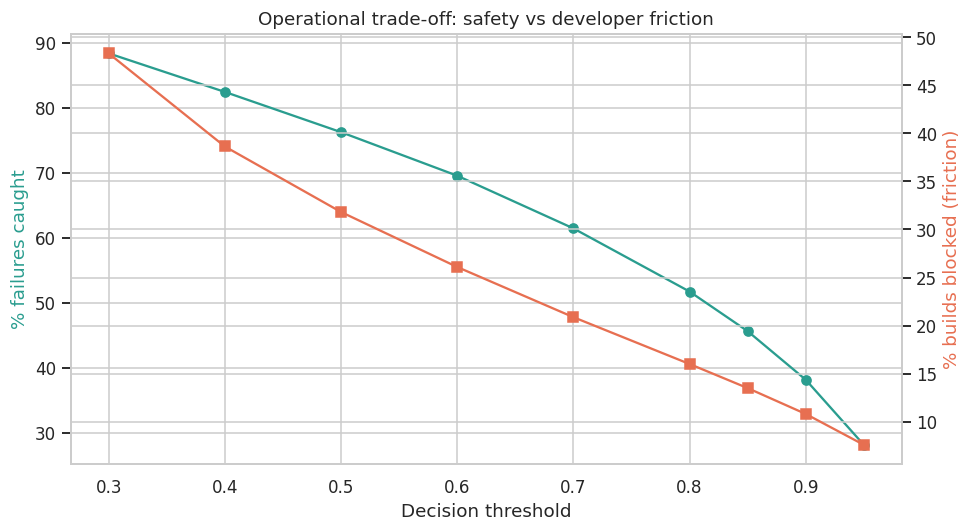

In [23]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(sim.threshold, sim.pct_failures_caught, marker='o', color='#2a9d8f',
         label='% of failures caught')
ax1.set_xlabel('Decision threshold'); ax1.set_ylabel('% failures caught', color='#2a9d8f')
ax2 = ax1.twinx()
ax2.plot(sim.threshold, sim.pct_builds_blocked, marker='s', color='#e76f51',
         label='% of all builds blocked')
ax2.set_ylabel('% builds blocked (friction)', color='#e76f51')
ax1.set_title('Operational trade-off: safety vs developer friction')
fig.tight_layout(); plt.savefig(f'{FIGURES}/13_gate_tradeoff.png', bbox_inches='tight')
plt.show()

### Optional: cost model

Turns the trade-off into a single defensible operating point and grounds your §1.2
motivation. Adjust the two constants to whatever you can justify from the literature.

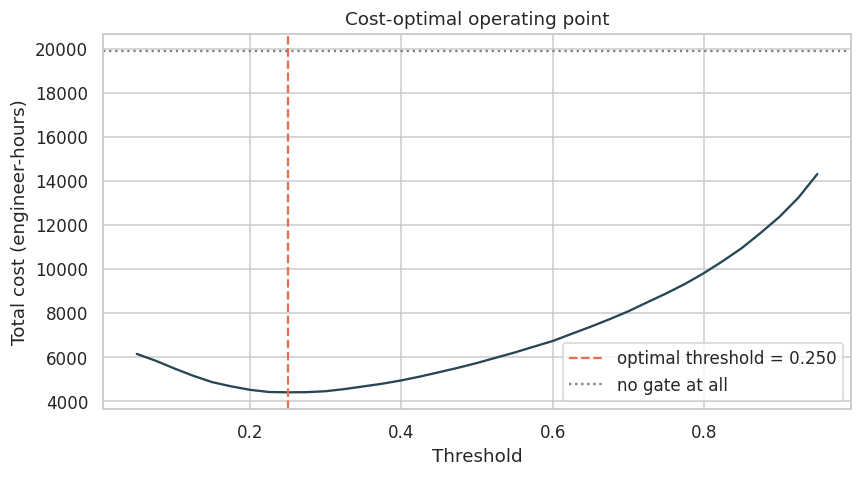

Optimal threshold      : 0.250
Cost with gate         : 4,406 engineer-hours
Cost without gate      : 19,898 engineer-hours
Estimated saving       : 15,492 hours (77.9%)

State your cost assumptions explicitly in the dissertation — they are assumptions.


In [24]:
COST_FAILURE_MIN = 45   # engineer-minutes lost to a failed build reaching main
COST_BLOCK_MIN   = 5    # minutes lost when a healthy build is wrongly delayed

def total_cost(t):
    pred = (p_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return fn * COST_FAILURE_MIN + fp * COST_BLOCK_MIN

ts = np.arange(0.05, 0.96, 0.025)
costs = [total_cost(t) for t in ts]
best = ts[int(np.argmin(costs))]
no_gate = (y_test == 1).sum() * COST_FAILURE_MIN

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ts, np.array(costs) / 60, color='#264653')
ax.axvline(best, ls='--', c='#e76f51', label=f'optimal threshold = {best:.3f}')
ax.axhline(no_gate / 60, ls=':', c='grey', label='no gate at all')
ax.set(xlabel='Threshold', ylabel='Total cost (engineer-hours)',
       title='Cost-optimal operating point')
ax.legend()
plt.tight_layout(); plt.savefig(f'{FIGURES}/14_cost_model.png', bbox_inches='tight')
plt.show()

print(f'Optimal threshold      : {best:.3f}')
print(f'Cost with gate         : {min(costs)/60:,.0f} engineer-hours')
print(f'Cost without gate      : {no_gate/60:,.0f} engineer-hours')
print(f'Estimated saving       : {(no_gate-min(costs))/60:,.0f} hours '
      f'({100*(no_gate-min(costs))/no_gate:.1f}%)')
print('\nState your cost assumptions explicitly in the dissertation — they are assumptions.')

## 13. Hyperparameter tuning (optional — run when you have time)

Expect only ~0.005–0.015 AUC improvement over the sensible defaults above. Report the
gain honestly rather than implying it was transformative. ~30–60 min on free Colab.

In [25]:
RUN_TUNING = False   # flip to True when you have a spare hour

if RUN_TUNING:
    param_dist = {
        'max_depth': [3, 4, 5, 6, 8, 10],
        'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
        'n_estimators': [300, 500, 800],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5, 7, 10],
        'reg_lambda': [0, 0.5, 1, 3, 10],
    }
    search = RandomizedSearchCV(
        xgb.XGBClassifier(scale_pos_weight=SCALE_POS_WEIGHT, eval_metric='aucpr',
                          n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist'),
        param_dist, n_iter=40, scoring='average_precision',
        cv=TimeSeriesSplit(n_splits=3), verbose=2, random_state=RANDOM_STATE, n_jobs=1)
    search.fit(X_train, y_train)
    print('Best params:', search.best_params_)
    print('Best CV PR-AUC:', round(search.best_score_, 4))
    json.dump(search.best_params_, open(f'{MODELS}/best_params.json', 'w'), indent=2)
    p_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
    evaluate('XGBoost (tuned)', y_test, p_tuned)
else:
    print('Tuning skipped. Set RUN_TUNING = True to run it.')

Tuning skipped. Set RUN_TUNING = True to run it.


## 14. Save the artefact for the API

Everything the FastAPI service needs. **Save the threshold and the feature order** —
a mismatched feature order at inference is a silent, hard-to-find bug.

In [26]:
import joblib

CHOSEN_THRESHOLD = THR_PREC85 if THR_PREC85 else THR_MAX_F1

joblib.dump(xgb_model, f'{MODELS}/xgb_model.joblib')
joblib.dump(scaler,    f'{MODELS}/scaler.joblib')

metadata = {
    'model_version': 'xgb-v1.0',
    'trained_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': len(FEATURES),
    'feature_order': FEATURES,
    'chosen_threshold': float(CHOSEN_THRESHOLD),
    'threshold_max_f1': float(THR_MAX_F1),
    'threshold_precision_85': (float(THR_PREC85) if THR_PREC85 else None),
    'train_rows': int(len(train)),
    'test_metrics': {k: float(v) for k, v in results['XGBoost'].items()
                     if isinstance(v, (int, float))},
    'dataset': 'TravisTorrent 8_2_2017',
    'label_definition': 'tr_status in {failed, errored} -> 1; passed -> 0',
}
json.dump(metadata, open(f'{MODELS}/model_metadata.json', 'w'), indent=2)

print('Saved:')
print(f'  {MODELS}/xgb_model.joblib')
print(f'  {MODELS}/scaler.joblib')
print(f'  {MODELS}/model_metadata.json')
print(f'\nOperating threshold: {CHOSEN_THRESHOLD:.3f}')

Saved:
  /content/drive/MyDrive/fyp-deployment-prediction/models/xgb_model.joblib
  /content/drive/MyDrive/fyp-deployment-prediction/models/scaler.joblib
  /content/drive/MyDrive/fyp-deployment-prediction/models/model_metadata.json

Operating threshold: 0.800


In [27]:
# inference latency — your proposal §4.6 asks for this
sample = X_test.iloc[:1]
_ = xgb_model.predict_proba(sample)          # warm up

lat = []
for _ in range(200):
    t0 = time.perf_counter()
    xgb_model.predict_proba(X_test.iloc[[np.random.randint(len(X_test))]])
    lat.append((time.perf_counter() - t0) * 1000)

print(f'Single-prediction latency  p50 = {np.percentile(lat,50):.2f} ms')
print(f'                           p95 = {np.percentile(lat,95):.2f} ms')
print(f'                           p99 = {np.percentile(lat,99):.2f} ms')
print('\nNote: this is model-only latency. Add HTTP + feature-assembly overhead')
print('when you measure the deployed FastAPI service end to end.')

Single-prediction latency  p50 = 22.86 ms
                           p95 = 29.12 ms
                           p99 = 31.05 ms

Note: this is model-only latency. Add HTTP + feature-assembly overhead
when you measure the deployed FastAPI service end to end.


---

## Results checklist

- [ ] XGBoost ROC-AUC in the 0.85–0.92 range (leakage tripwire passed)
- [ ] All three models compared, with bootstrap CIs
- [ ] Threshold sweep table and figure produced
- [ ] SHAP summary confirms history features dominate
- [ ] Ablation shows the history-feature contribution (~+0.24 AUC)
- [ ] Cross-project scores are worse than temporal — discussed, not hidden
- [ ] Gate simulation table produced
- [ ] Model artefact + metadata saved to Drive
- [ ] Latency measured

## Figures produced (all in `reports/figures/`)

`06_lr_coefficients` · `07_roc_pr_curves` · `08_threshold_sweep` · `09_confusion` ·
`10_shap_summary` · `11_shap_force` · `12_ablation` · `13_gate_tradeoff` · `14_cost_model`

Together with Notebook 01's figures 01–05, that is your entire results chapter.

## Next: the artefact

FastAPI service wrapping `xgb_model.joblib`, then GitHub Actions integration with the
three policy modes (shadow → warn → block), then the Streamlit dashboard.
See `DEVELOPMENT_GUIDE.md` Part 6.
